## Машинное обучение 1, ПМИ ФКН ВШЭ

## Практическое домашнее задание 1

## 1. Табличные данные и Pandas [4 балла]

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [4]:
data = pd.read_excel('./data/end_seminar.xlsx', engine='openpyxl')

In [5]:
data.tail(3)

,timestamp,id,rating,group_22,is_mi,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,percentile,group_21,blended,is_ml_student
426,2024-08-19 11:49:43.000,77b2b19d26b7f160c1938369197f7cac590b2e0cfcac3b...,1232,NaN,NaN,Принятие решений в условиях риска и неопределе...,Основы разработки компьютерных игр,Введение в платформы данных,Теория и практика онлайн-экспериментов,Конфликты и кооперация (преподается на английс...,Децентрализованные системы,Да,0.440252,212.0,Соревновательный анализ данных,NaN
427,2024-08-13 14:58:30.000,6dafd9a56d08aeb419166d314b0cd6f3107ae5e8dbd636...,961,NaN,NaN,Основы информационного поиска,Дизайн систем,Язык программирования Scala,Промышленное программирование на Haskell,Методы сжатия и передачи медиаданных,Децентрализованные системы,Да,0.858491,215.0,Безопасность систем на базе LLM,NaN
428,2024-08-13 18:35:25.235,4bf710d7b89064e1a3cbcc69b7ca67c20d6181dc72ad35...,1374,NaN,NaN,Трансформерные и мультимодальные модели,Глубинное обучение для текстовых данных,Self-supervised Learning,Обучение с подкреплением,Современные языковые модели,Развёртывание ML-моделей в высоконагруженных с...,Да,0.169811,217.0,Продуктовый подход к анализу данных,NaN


In [6]:
student_22 = data[data['group_22'].notna()]['id'].nunique()

student_21 = data[data['group_21'].notna()]['id'].nunique()

print(student_22, student_21)

259 159


In [7]:
student  = data[data.duplicated(subset=['percentile'])]['id'].nunique()

print(student)

97


In [8]:
data['is_mi'] = data['is_mi'].fillna(0.0)
data['group_21'] = data['group_21'].fillna(0.0)
data['group_22'] = data['group_22'].fillna(0.0)
data['blended'] = data['blended'].fillna('')
data['is_ml_student'] = data['is_ml_student'].fillna(0.0)
data['spring_1'] = data['spring_1'].fillna('')
data['spring_2'] = data['spring_2'].fillna('')
data['spring_3'] = data['spring_3'].fillna('')

In [9]:
percent = data['is_first_time'].value_counts(normalize=True) * 100

print(percent)
print((data['is_first_time'] == 'Нет').sum())

is_first_time
Да     94.871795
Нет     5.128205
Name: proportion, dtype: float64
22


In [10]:
data = data.drop_duplicates(subset = ['id'], keep = 'last')
data = data.drop(columns = ['is_mi'])

In [11]:
data.head()

,timestamp,id,rating,group_22,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,percentile,group_21,blended,is_ml_student
0,2024-08-12 00:01:06,8a95d7276b95b8b9c4cf8a5b402e98617ad7452977f6e6...,737,226.0,Разработка микросервисов на Go,Язык SQL,Распределенные системы,Компьютерные сети,Язык программирования Go,Промышленное программирование на языке Java,Да,0.144444,0.0,,0.0
1,2024-08-14 00:00:22,289897d0cf42b4b42c50300f94b8b86f913174ae972d96...,486,2210.0,Распределенные системы,Основы информационного поиска,Основы разработки компьютерных игр,Рекомендательные системы,Дополнительные главы машинного обучения,Стохастический анализ,Да,0.796296,0.0,,1.0
2,2024-08-13 18:16:33,01f548f29a80a6f35b8ce1bdfdf723e2ba70a9c074c2f9...,494,223.0,Statistical Learning Theory,Распределенные системы,Основы тензорных вычислений,Стохастический анализ,Специальные разделы матричного анализа,Математические основы нейросетевых моделей,Да,0.774074,0.0,,1.0
3,2024-08-14 10:22:37,68e3e62f6e017e43094bb63b4dde0b0229564cece838b5...,753,225.0,Разработка микросервисов на Go,Язык SQL,Безопасность компьютерных систем,Промышленное программирование на языке Java,Промышленное программирование на языке Java,Промышленное программирование на языке Java,Да,0.096296,0.0,,0.0
4,2024-08-14 20:52:05,aac63ca42c5701a219d0e4f3289e17ed3160d5a2279790...,685,221.0,Типы в языках программирования,Основы информационного поиска,Системы баз данных,Дополнительные главы машинного обучения,Генеративные модели в машинном обучении (углуб...,Моделирование временных рядов,Да,0.275926,0.0,,1.0


In [12]:
data['blended'].dropna().nunique()

7

In [13]:
data[data['blended'] != '']['blended'].value_counts().idxmax()

'Протоколы доказательств с нулевым разглашением'

In [14]:
blended_student = data[data['blended'] != '']
blended_rating = blended_student.groupby('blended')['rating'].agg(['mean','count'])

bst_rt = blended_rating['mean'].idxmax()

print(bst_rt,f"\n",blended_rating.loc[bst_rt, 'count'])

Продуктовый подход к анализу данных 
 25


In [15]:
data_columns = ['fall_1', 'fall_2', 'fall_3', 'spring_1', 'spring_2', 'spring_3', 'blended']

new_data = data.groupby(data_columns).size().reset_index(name = 'count')

new_data = new_data[new_data['count'] > 1]

new_data

,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,blended,count
13,Statistical Learning Theory,Основы информационного поиска,Язык SQL,Дополнительные главы машинного обучения,Машинное обучение в прикладных задачах,Аналитика данных,,2
60,Безопасность компьютерных систем,Основы разработки компьютерных игр,Язык SQL,Компьютерные сети,Компьютерные сети,Компьютерные сети,,2
134,Дизайн систем,Безопасность компьютерных систем,Основы разработки компьютерных игр,Децентрализованные системы,Методы сжатия и передачи медиаданных,Теория и практика онлайн-экспериментов,Протоколы доказательств с нулевым разглашением,2
135,Дизайн систем,Безопасность компьютерных систем,Основы разработки компьютерных игр,Децентрализованные системы,Промышленное программирование на Haskell,Обучение с подкреплением,Протоколы доказательств с нулевым разглашением,2
142,Дизайн систем,Операционные системы 2,Основы информационного поиска,Промышленное программирование на Haskell,Децентрализованные системы,Методы сжатия и передачи медиаданных,Протоколы доказательств с нулевым разглашением,2
282,Системы баз данных,Операционные системы 2,Безопасность компьютерных систем,,,,,2
288,Системы баз данных,Операционные системы 2,Разработка микросервисов на Go,,,,,2
290,Системы баз данных,Операционные системы 2,Разработка микросервисов на Go,Компьютерные сети,Компьютерные сети,Компьютерные сети,,2
293,Системы баз данных,Операционные системы 2,Функциональное программирование,,,,,2
309,Системы баз данных,Разработка микросервисов на Go,Операционные системы 2,Компьютерные сети,Промышленное программирование на языке Java,Машинное обучение 2,,2


In [16]:
curses_columns = ['fall_1', 'fall_2','fall_3', 'spring_1', 'spring_2', 'spring_3', 'blended']

mask_21 = (data['group_21'] >= 210) & (data['group_21'] < 220)
mask_22 = (data['group_22'] >= 220) & (data['group_22'] < 230)

courses_21 = set(data[mask_21][curses_columns].stack().unique())
courses_22 = set(data[mask_22][curses_columns].stack().unique())

courses_21.discard('')
courses_22.discard('')

print(courses_21 & courses_22)

{'Стохастический анализ', 'Типы в языках программирования', 'Основы разработки компьютерных игр', 'Безопасность компьютерных систем', 'Принятие решений в условиях риска и неопределенности', 'Математические основы нейросетевых моделей', 'Основы тензорных вычислений', 'Основы информационного поиска', 'Специальные разделы матричного анализа', 'Statistical Learning Theory', 'Язык программирования Scala', 'Операционные системы 2', 'Интегральные уравнения в задачах математического моделирования', 'Введение в платформы данных'}


In [17]:
only_21 = courses_21 - courses_22

only_22 = courses_22 - courses_21

print(only_21)
print("#----------#")
print(only_22)

{'Байесовские методы в машинном обучении', 'Эксплуатация и надёжность программных систем', 'Современные языковые модели', 'Безопасность систем на базе LLM', 'Конфликты и кооперация (преподается на английском языке)', 'Теория сложных систем', 'Дизайн систем', 'Глубинное обучение в обработке звука', 'Трехмерное компьютерное зрение', 'Введение в дифференциальную геометрию', 'Децентрализованные системы', 'Продуктовый подход к анализу данных', 'Генеративные модели на основе диффузии', 'ML System Design', 'Соревновательный анализ данных', 'Протоколы доказательств с нулевым разглашением', 'Теория и практика онлайн-экспериментов', 'Символьные вычисления', 'Self-supervised Learning', 'Глубинное обучение для текстовых данных', 'Глубинное обучение в анализе графовых данных', 'Генеративные модели на основе диффузии / Diffusion-Based Generative Models', 'Эффективные системы глубинного обучения', 'Генеративные модели в машинном обучении', 'Развёртывание ML-моделей в высоконагруженных системах', 'Про

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12
mpl.rcParams['savefig.format'] = 'pdf'
sns.set_style('darkgrid')


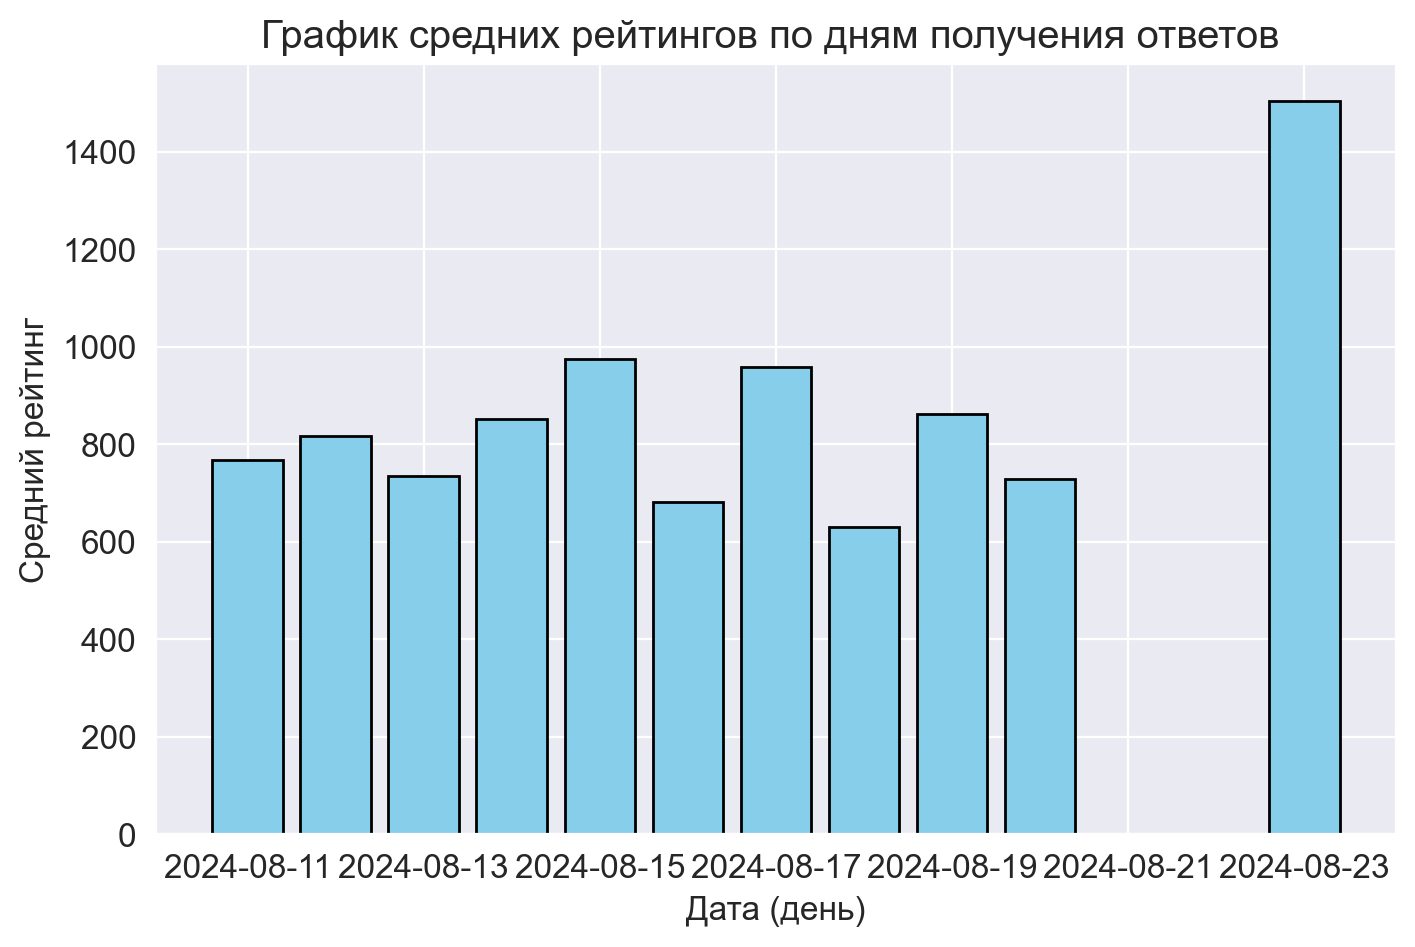

<Figure size 800x500 with 0 Axes>

In [19]:
mean_rating = data.groupby(data['timestamp'].dt.date)['rating'].mean()

plt.bar(mean_rating.index, mean_rating.values, color='skyblue', edgecolor='black')
plt.title('График средних рейтингов по дням получения ответов ')
plt.xlabel('Дата (день)')
plt.ylabel('Средний рейтинг')
plt.show()
plt.savefig('hw_practice-01-pandas-finnik.pdf', dpi=600)

## 2. Распределение студентов по курсам. (6 баллов + 1 бонус)

#### 0. Проверка

Для начала давайте убедимся, что вы успешно выполнили задания первой части и проверим ваши данные на наличие пропусков и повторов:

In [20]:
assert data.shape == (418, 15), 'В таблице остались повторы или потеряны данные'
assert data.isna().sum().sum() == 0, 'В таблице остались пропуски'

#### 1. [1 балл] Создайте новый признак, обозначающий, сколько осенних курсов должен выбрать студент

В этом вам может помочь информация о специализации и группе стундента.

In [21]:
columns_fall_1 = ['fall_1','percentile','is_ml_student','id']

data_fall_1 = data.groupby(columns_fall_1).size().reset_index(name = 'count')

data_fall_1.sort_values('percentile', ascending = False, inplace = True)

# data_fall_1

#### проверка:

In [ ]:
col_name = ''

assert(data[data['id'] == 'bcca318e644999583156ff3ab9de3d6bd02295dcb166e39006568ffe9582207b'][col_name] == 1).all()
assert(data[data['id'] == 'edb64996c64421378537d941a77426a5a7bd84f9967ad9f523ca61386e5469ed'][col_name] == 1).all()
assert(data[data['id'] == '5f96908e3ce5d84d693ddd79670d60cd1c6a02646aa779f46586a7699dda7c25'][col_name] == 1).all()
assert(data[data['id'] == '0f137538a170b64258c0e10839cadc325e5f22fc5bb5fa9e20b7351f0a680366'][col_name] == 2).all()

#### 2. [2 балла] Распределите студентов в соответствии с первым приоритетом

In [24]:
df_subset = data[['id', 'percentile', 'is_ml_student', 'fall_1', 'fall_2', 'fall_3']]

requests = df_subset.melt(
    id_vars=['id', 'percentile', 'is_ml_student'],
    value_vars=['fall_1', 'fall_2', 'fall_3'],
    var_name='priority',
    value_name='course'
)

requests = requests.dropna(subset=['course'])
requests = requests[requests['course'] != '']

In [25]:

all_fall_courses = requests['course'].unique()
all_fall_courses = [course for course in all_fall_courses if course != '']

capacity = pd.Series(30, index=all_fall_courses)
capacity['Количественные финансы'] = 60
capacity['Промышленное программирование на Haskell'] = 60
capacity['Рекомендательные системы'] = 60
capacity['Глубинное обучение в обработке звука'] = 1000

In [26]:
requests['wave'] = requests['priority'].map({'fall_1': 1, 'fall_2': 2, 'fall_3': 3})

is_ml = requests['is_ml_student'] == True
requests.loc[is_ml & (requests['priority'] == 'fall_2'), 'wave'] = 1
requests.loc[is_ml & (requests['priority'] == 'fall_3'), 'wave'] = 2

requests = requests.sort_values(by=['wave', 'percentile'])

In [27]:
student_needs = pd.Series(1, index=data['id'])

ml_ids = data[data['is_ml_student'] == 1]['id']

student_needs.loc[ml_ids] = 2

# student_needs.head(20)

In [28]:
successful_allocations = []

for wave in [1, 2, 3]:

    current_reqs = requests[requests['wave'] == wave].copy()

    current_reqs['need'] = current_reqs['id'].map(student_needs)
    current_reqs = current_reqs[current_reqs['need'] > 0]

    if current_reqs.empty:
        continue

    current_reqs = current_reqs.sort_values(by=['percentile', 'priority'])
    current_reqs['student_req_num'] = current_reqs.groupby('id').cumcount()
    current_reqs = current_reqs[current_reqs['student_req_num'] < current_reqs['need']]

    current_reqs['place_in_line'] = current_reqs.groupby('course').cumcount()

    current_reqs['places_left'] = current_reqs['course'].map(capacity)

    accepted = current_reqs[current_reqs['place_in_line'] < current_reqs['places_left']]

    successful_allocations.append(accepted)

    course_counts = accepted['course'].value_counts()
    capacity = capacity.sub(course_counts, fill_value=0)

    student_counts = accepted['id'].value_counts()
    student_needs = student_needs.sub(student_counts, fill_value=0)

final_allocations = pd.concat(successful_allocations)
final_allocations.head(30)

,id,percentile,is_ml_student,priority,course,wave,need,student_req_num,place_in_line,places_left
122,43356e961c7491ef55887c470a7d1fcb69e62000fdf660...,0.000000,1.0,fall_1,Прикладная статистика в машинном обучении,1,2.0,0,0,30.0
325,92f4503e31c17e957f5c5ce045c496f440b0565d37f9aa...,0.000000,1.0,fall_1,Глубинное обучение для текстовых данных,1,2.0,0,0,30.0
540,43356e961c7491ef55887c470a7d1fcb69e62000fdf660...,0.000000,1.0,fall_2,Основы информационного поиска,1,2.0,1,0,30.0
743,92f4503e31c17e957f5c5ce045c496f440b0565d37f9aa...,0.000000,1.0,fall_2,Self-supervised Learning,1,2.0,1,0,30.0
25,11daff8d676cc1cd424d403804ff0b44caa6b22e3d56f8...,0.003704,0.0,fall_1,Прикладная статистика в машинном обучении,1,1.0,0,1,30.0
288,f5de8b91d28d8d19bf721b14fce50112083c5a51b18c20...,0.006289,0.0,fall_1,Операционные системы 2,1,1.0,0,0,30.0
135,69c23d81afb1431da28fdec9e1edf407dbca5ab0fab273...,0.007407,0.0,fall_1,Введение в платформы данных,1,1.0,0,0,30.0
115,79da3965a7836de9a314e56f4f632e7103ce3af0af5389...,0.011111,0.0,fall_1,Язык SQL,1,1.0,0,0,30.0
309,18b2e3f22341a710bc89ceeaafb3045a17a9eafe748b9f...,0.012579,0.0,fall_1,Основы разработки компьютерных игр,1,1.0,0,0,30.0
238,6e1190bb70002259960601e0c4984c1c068a2d88c508f5...,0.014815,0.0,fall_1,Безопасность компьютерных систем,1,1.0,0,0,30.0


In [29]:
result_df = final_allocations[['id', 'course']].copy()

result_df['course_num'] = result_df.groupby('id').cumcount() + 1
result_df['course_num'] = 'course' + result_df['course_num'].astype(str)

res_fall = result_df.pivot(index='id', columns='course_num', values='course').reset_index()

res_fall = pd.merge(data[['id', 'is_ml_student']], res_fall, on='id', how='left')

res_fall['course1'] = res_fall['course1'].fillna('???')

is_ml = res_fall['is_ml_student'] == 1

res_fall.loc[is_ml & res_fall['course2'].isna(), 'course2'] = '???'
res_fall.loc[~is_ml & res_fall['course2'].isna(), 'course2'] = '-'

# Оставляем только нужные колонки
res_fall = res_fall[['id', 'course1', 'course2']]

res_fall.to_csv('res_fall.csv')
res_fall.head()

,id,course1,course2
0,8a95d7276b95b8b9c4cf8a5b402e98617ad7452977f6e6...,Разработка микросервисов на Go,-
1,289897d0cf42b4b42c50300f94b8b86f913174ae972d96...,Распределенные системы,Основы информационного поиска
2,01f548f29a80a6f35b8ce1bdfdf723e2ba70a9c074c2f9...,Statistical Learning Theory,Распределенные системы
3,68e3e62f6e017e43094bb63b4dde0b0229564cece838b5...,Разработка микросервисов на Go,-
4,aac63ca42c5701a219d0e4f3289e17ed3160d5a2279790...,Типы в языках программирования,Основы информационного поиска


<img src="https://media1.tenor.com/m/im0hdXvcn9wAAAAC/patrick-spongebob.gif" style="width: 400px">

### 4. [1 балла] Распределите таким же образом студентов еще и на весенние курсы по выбору.

Если ваш код был хорошо структурирован, то это не составит проблем.

Если вы выполнили это задание, сдайте среди прочего файл res_spring.csv в таком же формате, как и res_fall.csv.

In [30]:
df_spring = data[['id', 'percentile', 'is_ml_student', 'spring_1', 'spring_2', 'spring_3']]

requests_spring = df_spring.melt(
    id_vars=['id', 'percentile', 'is_ml_student'],
    value_vars=['spring_1', 'spring_2', 'spring_3'],
    var_name='priority',
    value_name='course'
)

requests_spring = requests_spring.dropna(subset=['course'])
requests_spring = requests_spring[requests_spring['course'] != '']

In [ ]:
all_spring_courses = requests_spring['course'].unique
all_spring_courses = [course for course in all_spring_courses if course != '']

capacity = pd.Series(30, index=all_spring_courses)
capacity['Количественные финансы'] = 60
capacity['Промышленное программирование на Haskell'] = 60
capacity['Рекомендательные системы'] = 60
capacity['Глубинное обучение в обработке звука'] = 1000